# OOPAO + 算法 1 仿真逐步调试 Notebook

对 **beaconless-ao-sim** 的物理仿真流水线（`data/simulate.py`）做逐步可视化调试，每个单元对应算法 1 的一个阶段（参见 `REPORT.md` §1.1-1.4 与论文 DiComo 等，*Opt. Express* 33(15):31010 (2025)，DOI 10.1364/OE.561077）。

湍流屏由 **OOPAO** 提供，参考：

- OOPAO 文档主页：<https://cheritier.github.io/OOPAO/index.html>
- [`Atmosphere`](https://cheritier.github.io/OOPAO/atmosphere.html)：多层 von-Karman 相位屏（基于 `phaseStats.ft_sh_phase_screen`，源自 aotools）。
- [`Telescope`](https://cheritier.github.io/OOPAO/telescope.html)：圆形孔径几何，采样网格 `resolution = N`。
- [`Source`](https://cheritier.github.io/OOPAO/source.html)：点源 + 波长带（`optBand`）；本文用 `optBand="R"`（λ ≈ 650 nm，仅用于 OPD 单位约定，OPD 本身以弧度计算）。
- [`Zernike`](https://cheritier.github.io/OOPAO/zernike.html)：Noll 序 Zernike 多项式基底。
- [Phase Statistics](https://cheritier.github.io/OOPAO/phase_stats.html)：`ft_sh_phase_screen`（OOPAO 内部用，源自 aotools）。

本项目里 OOPAO 的接入点：

- `physics/oopao_backend.py` 中的 `OopaoScreenBackend`：构建一次 `Atmosphere`（参考 r0 = 0.15 m @ 500 nm），用 `Atmosphere.generateNewPhaseScreen(seed)` 抽取每层屏，再以 `(r0_slab / r0_ref)^(5/6)` 把每层振幅缩放到目标 per-slab r0，并中心裁剪到 `N × N`。
- `data/simulate.py`：用 `shared.oopao.make_screens(seed)` 替换 `_make_screens` 里的 aotools 路径（`beam_source == "oopao"`）。

**运行方式**：
```bash
uv run jupyter notebook data/oopao_simulation_debug.ipynb
```
（或 VS Code 直接打开；内核选 `.venv`）。

**调试技巧**：
- 改 `cfg` 后重跑「§1 构建共享状态」单元，使新参数生效。
- 单次 `simulate_sample` 约 5-6 s（含 10 层 OOPAO 屏 + 10 个粗糙面 realization）。
- 每个 step 单元都可视化对应阶段的关键中间量，方便定位数值/几何异常。


## 算法 1 全流程图（来自 `REPORT.md` §1.1）

```mermaid
flowchart TD
    A["聚焦高斯光束<br/>束腰 λL/D"] --> B["10 层 OOPAO<br/>von-Karman 相位屏<br/>间隔 100 m / 1 km"]
    B --> C["分步 FFT 传播<br/>propagation_fft"]
    C --> D["目标面 1 km<br/>散射 / 粗糙表面"]
    D --> E["算法 1 导引信标<br/>衍射极限高斯"]
    E --> F["反向传播至瞳孔<br/>+ 解析抛物面离焦移除"]
    F --> G["共轭信标相位<br/>Φ_beacon"]
    G --> H["Zernike 投影<br/>Φ_Z78"]
    H --> I["CNN 目标<br/>78 阶 Noll 系数"]
    G --> J["倾斜 / 倾斜跟踪"]
    D --> K["3 测量平面成像<br/>-zR / 0 / +zR"]
    K --> L["非相干平均<br/>+ 吸收边界"]
    L --> M["12-bit 逐图像量化"]
    M --> N["输入 3x512x512<br/>uint16/2047"]
    I --> O["训练 CNN1"]
    N --> O
```

下方每个章节对应算法 1 的一个步骤。


## §0. 环境准备 + 配置加载

导入依赖；加载 `config.yaml`；启用 inline 绘图与中文字体。所有后续单元依赖这里的 `cfg`。


In [1]:
import os
import sys
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

ROOT = os.path.dirname(os.path.abspath(''))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from physics.config import load_config

cfg = load_config(os.path.join(ROOT, 'config.yaml'))

mpl.rcParams['figure.dpi'] = 110
mpl.rcParams['image.cmap'] = 'inferno'
for cand in ('Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'PingFang SC'):
    if cand in {f.name for f in mpl.font_manager.fontManager.ttflist}:
        mpl.rcParams['font.sans-serif'] = [cand, 'DejaVu Sans']
        break
mpl.rcParams['axes.unicode_minus'] = False

print('ROOT =', ROOT)
print('beam_source =', cfg.physical.beam_source)
print('N =', cfg.physical.N, '  L =', cfg.physical.L, 'm  lam =', float(cfg.physical.wavelength)*1e9, 'nm')


ROOT = /home/ws/code/beaconless-ao-sim
beam_source = oopao
N = 512   L = 1000.0 m  lam = 800.0 nm


## §1. 构建 `SharedSim`（传播器、Zernike 基底、网格、光束）

`_get_shared(cfg)` 一次性构建整个进程复用、跨样本不变的重计算量：

- `Propagator`（FFT 分步传播器，FFTW 初始化约 1-3 s）
- `ZernikeBasis`（78 阶 Noll 基，伪逆约 1 s）
- 坐标网格 `X/Y/r2`、孔径掩膜 `pupil`、跟踪高斯权重 `G`
- 入瞳光束 `E0`、聚焦相位 `phi_focus`、真空目标面强度 `I_vac`
- 成像几何 `zR_APWS / f_obj / plane_offsets`（公式 9-12 解析解）
- `oopao: OopaoScreenBackend`（仅当 `beam_source == "oopao"`）

**调试点**：800 nm / Cn² = 8.13e-15 / L = 1 km 时 `zR_APWS ≈ 642 m`、`f_obj ≈ 1285 m`，对应 `D/r0 ≈ 7.4`（强湍流）。


In [2]:
from data.simulate import (
    _beacon_phase_conj,
    _fom_leg,
    _get_shared,
    _imaging,
    _make_screens,
    _quantize,
    _tracking,
    simulate_sample,
)

t0 = time.time()
shared = _get_shared(cfg)
print(f'共享状态构建耗时 {time.time()-t0:.1f} s')

print(f'N = {shared.N}   dx = {shared.dx*1e3:.3f} mm   lam = {shared.lam*1e9:.0f} nm')
print(f'rspot = {shared.rspot*1e2:.1f} cm   focal = {shared.focal:.0f} m')
print(f'zR_APWS = {shared.zR_APWS:.2f} m   f_obj = {shared.f_obj:.2f} m')
print(f'plane_offsets (m) = {np.round(shared.plane_offsets, 2)}')
print('  (plane 0 = f_obj - zR, plane 1 = 焦平面, plane 2 = f_obj + zR)')
print(f'E0 max = {np.abs(shared.E0).max():.3f}   pupil pixels = {int(shared.pupil.sum())}')
print(f'I_vac max = {shared.I_vac.max():.4f}   oopao backend: {shared.oopao is not None}')


CuPy is not found, using NumPy backend...



------------ Telescope -------------
Diameter [m]             |   1.00   
Resolution [px]          |    8     
Pixel size [m]           |   0.12   
Surface [m²]             |   0.81   
Central obstruction [%]  |    0     
Pixels in pupil          |    52    
Field of view [arcsec]   |   0.00   
------------------------------------


------------ Telescope -------------
Diameter [m]             |   0.30   
Resolution [px]          |   512    
Pixel size [m]           |   0.00   
Surface [m²]             |   0.07   
Central obstruction [%]  |    0     
Pixels in pupil          |  205892  
Field of view [arcsec]   |   0.00   
------------------------------------

Creation of layer1/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.11977362632751465 s
Creation of layer2/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.08205461502075195 s
Creation of layer3/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.08198928833007812 s
Creation of layer4/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.08237552642822266 s
Creation of layer5/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.08123898506164551 s
Creation of layer6/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.08135676383972168 s
Creation of layer7/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.08138871192932129 s
Creation of layer8/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.08179211616516113 s
Creation of layer9/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.08168339729309082 s
Creation of layer10/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.08191561698913574 s
Updating the Atmosphere covariance matrices...



------------------------- Atmosphere @ Elevation = 90.0°--------------------------
 Layer | Direction | Speed | Altitude | Frac Cn² | Diameter |     Evolution      |
       |    [°]    | [m/s] |   [m]    |   [%]    |   [m]    |                    |
   1   |     0     | 10.0  |  5e+01   |    10    |  0.302   |    Frozen Flow     |
   2   |     0     | 10.0  |  2e+02   |    10    |  0.302   |    Frozen Flow     |
   3   |     0     | 10.0  |  2e+02   |    10    |  0.302   |    Frozen Flow     |
   4   |     0     | 10.0  |  4e+02   |    10    |  0.302   |    Frozen Flow     |
   5   |     0     | 10.0  |  4e+02   |    10    |  0.302   |    Frozen Flow     |
   6   |     0     | 10.0  |  6e+02   |    10    |  0.302   |    Frozen Flow     |
   7   |     0     | 10.0  |  6e+02   |    10    |  0.302   |    Frozen Flow     |
   8   |     0     | 10.0  |  8e+02   |    10    |  0.302   |    Frozen Flow     |
   9   |     0     | 10.0  |  8e+02   |    10    |  0.302   |    Frozen Flow     |
  1

### §1.1 可视化：入瞳光束 / 聚焦相位 / 真空目标面

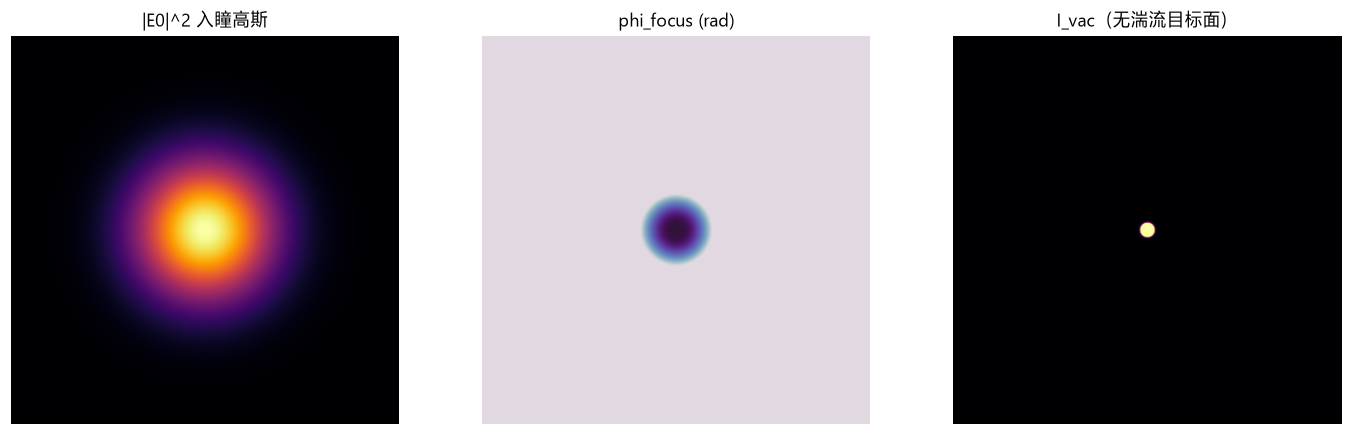

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(np.abs(shared.E0)**2); ax[0].set_title('|E0|^2 入瞳高斯'); ax[0].axis('off')
ax[1].imshow(shared.phi_focus, cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax[1].set_title('phi_focus (rad)'); ax[1].axis('off')
ax[2].imshow(shared.I_vac, vmin=0, vmax=np.percentile(shared.I_vac, 99.9))
ax[2].set_title('I_vac（无湍流目标面）'); ax[2].axis('off')
plt.tight_layout(); plt.show()


## §2. 步骤 A：OOPAO 湍流屏 `Atmosphere` → 10 层 von-Karman 相位屏

对应 OOPAO 文档：

- [`Atmosphere.generateNewPhaseScreen`](https://cheritier.github.io/OOPAO/atmosphere.html)：按 `seed` 重置每层的 `phaseStats.ft_sh_phase_screen`（OOPAO 内部由 aotools 移植），输出 `layer_i.OPD`（弧度，未做 `2π/λ` 转换）。
- [`Atmosphere.initializeAtmosphere`](https://cheritier.github.io/OOPAO/atmosphere.html)：构造每层并（可选）计算协方差矩阵。我们 `compute_covariance=False`，不进入 OOPAO 的 WFS/CL 工具链，只取屏本身。

本项目里 `OopaoScreenBackend` 流程：
1. 构建参考 r0 = 0.15 m @ 500 nm 的 10 层大气；
2. `generateNewPhaseScreen(seed)` 抽 10 层 516×516（含 2 px frozen-flow 边带）；
3. 中心裁剪到 512×512；
4. 每层振幅 × `(r0_slab / r0_ref)^(5/6)`，得到与 aotools 路径等价的 per-slab r0。

**调试点**：每层 OPD 标准差应稳定在 ~1.3 rad（与 aotools ~1.27 rad 比值 ≈ 1.06，落在采样噪声内）。


屏幕生成耗时 0.66 s   shape = (10, 512, 512)


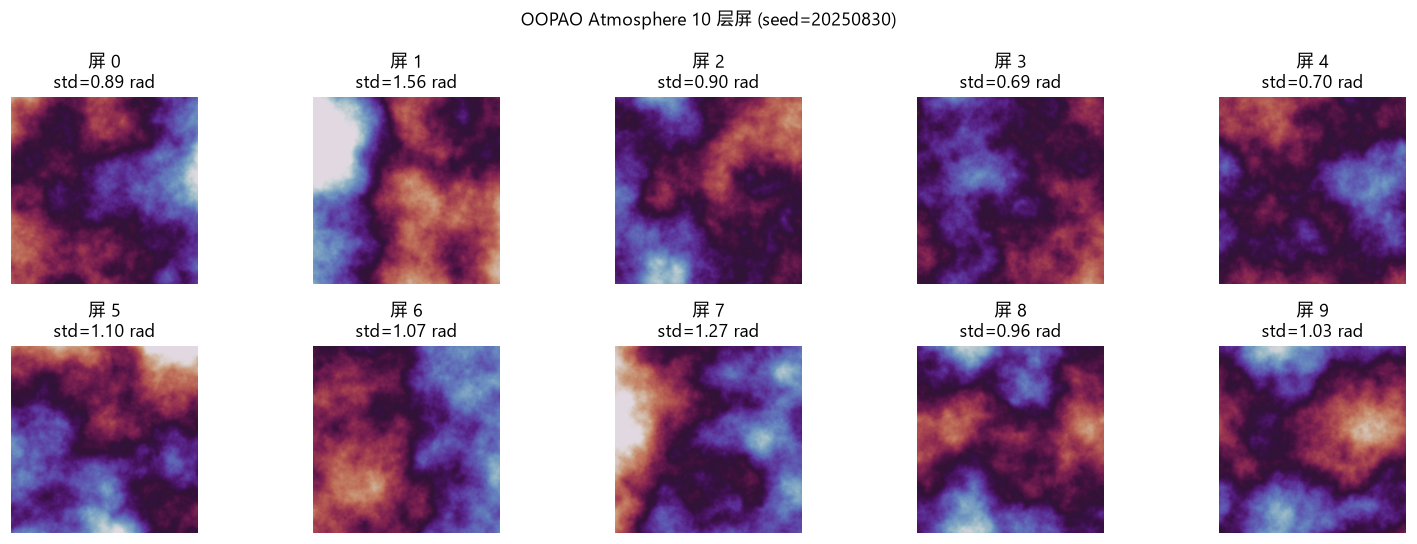

每层 OPD std (rad) = [0.888 1.565 0.899 0.692 0.699 1.096 1.068 1.272 0.961 1.031]


In [4]:
SEED = int(cfg.data.master_seed)
t0 = time.time()
screens = _make_screens(SEED, cfg, shared)
print(f'屏幕生成耗时 {time.time()-t0:.2f} s   shape = {screens.shape}')

fig, ax = plt.subplots(2, 5, figsize=(14, 5))
for i, a in enumerate(ax.flat):
    if i < screens.shape[0]:
        a.imshow(screens[i], cmap='twilight', vmin=-3, vmax=3)
        a.set_title(f'屏 {i}\nstd={screens[i].std():.2f} rad')
    a.axis('off')
plt.suptitle(f'OOPAO Atmosphere 10 层屏 (seed={SEED})')
plt.tight_layout(); plt.show()

print('每层 OPD std (rad) =', np.round(screens.std(axis=(1,2)), 3))


### §2.1 对比 OOPAO 屏 vs aotools 屏（`beam_source: "aotools"`）

切换 `cfg['physical']['beam_source']` 后重建 `shared`，用相同 seed 比较两条路径的统计量。两者在统计上应等价（per-slab r0 相同）。


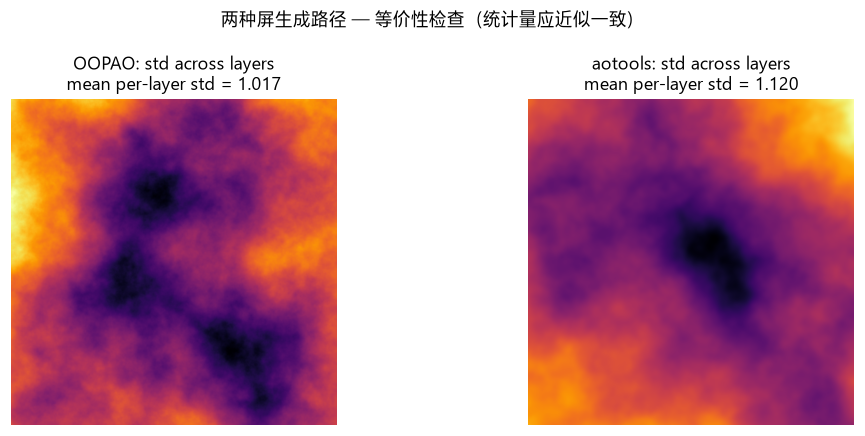

In [5]:
import copy
cfg_alt = copy.deepcopy(cfg)
cfg_alt.physical.beam_source = 'aotools'
shared_alt = _get_shared(cfg_alt)
screens_aotools = _make_screens(SEED, cfg_alt, shared_alt)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (name, scr) in zip(ax, [('OOPAO', screens), ('aotools', screens_aotools)]):
    a.imshow(scr.std(axis=0), cmap='inferno')
    a.set_title(f'{name}: std across layers\nmean per-layer std = {scr.std(axis=(1,2)).mean():.3f}')
    a.axis('off')
plt.suptitle('两种屏生成路径 — 等价性检查（统计量应近似一致）')
plt.tight_layout(); plt.show()

cfg.physical.beam_source = 'oopao'
shared = _get_shared(cfg)


## §3. 步骤 B+C：聚焦光束前向分步传播 → 湍流下的目标面强度

入瞳场 `E0 e^{i phi_focus}` 经 10 层屏做 `dz = 100 m` 分步传播到 `L = 1000 m` 目标面：`split_step(E, screens, dz)`（`physics/propagation_fft.py`）。这给出 `_fom_leg` 中的 `I_obj_noao`。

**调试点**：真空下 `I_vac` 应是一颗亮的衍射极限核（无湍流）；加入屏后会出现明显的散斑/闪烁。


前向 split_step 耗时 0.41 s


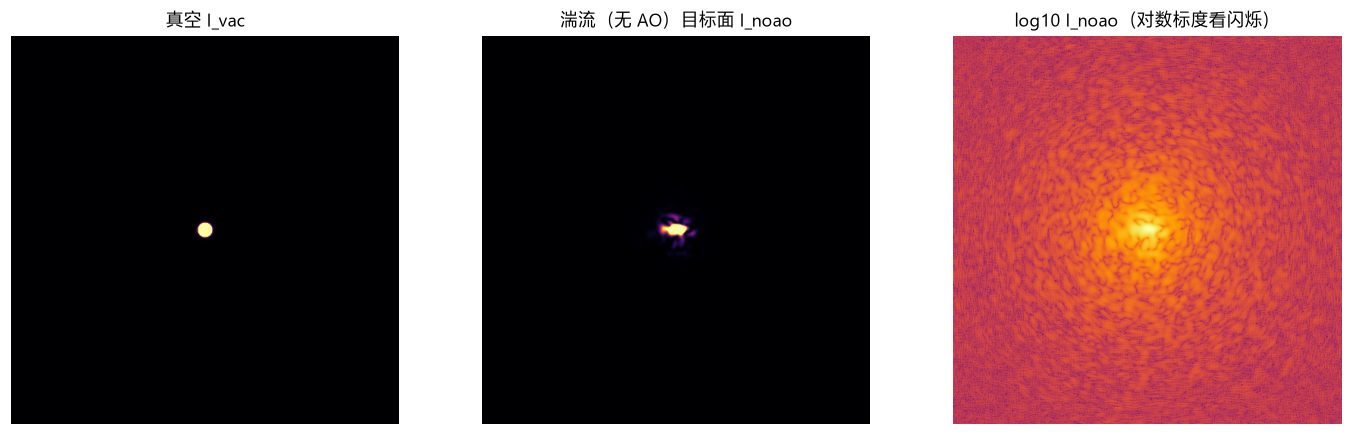

In [6]:
phi_focus = shared.phi_focus
E_in = (shared.E0 * np.exp(1j * phi_focus)).astype(np.complex64)
t0 = time.time()
E_noao = shared.prop.split_step(E_in, screens, shared.dz)
I_noao = (np.abs(E_noao)**2).astype(np.float32)
print(f'前向 split_step 耗时 {time.time()-t0:.2f} s')

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(shared.I_vac, vmin=0, vmax=np.percentile(shared.I_vac, 99.9))
ax[0].set_title('真空 I_vac'); ax[0].axis('off')
ax[1].imshow(I_noao, vmin=0, vmax=np.percentile(I_noao, 99.9))
ax[1].set_title('湍流（无 AO）目标面 I_noao'); ax[1].axis('off')
ax[2].imshow(np.log10(I_noao + 1e-12), cmap='inferno')
ax[2].set_title('log10 I_noao（对数标度看闪烁）'); ax[2].axis('off')
plt.tight_layout(); plt.show()


## §3.1 直接反向传播 `E_noao` — 原相位 vs 均匀相位

将 §3 得到的目标面场 `E_noao`（含湍流相位扰动）直接反向传播回瞳孔处，分别用：

- **原相位**：保留 `E_noao` 的完整复数场（振幅 + 相位）
- **均匀相位**：仅保留振幅 `|E_noao|`，相位设为零

对比两者在瞳孔处的光斑分布，帮助理解湍流相位在往返传播中的作用。

反向传播耗时 0.81 s


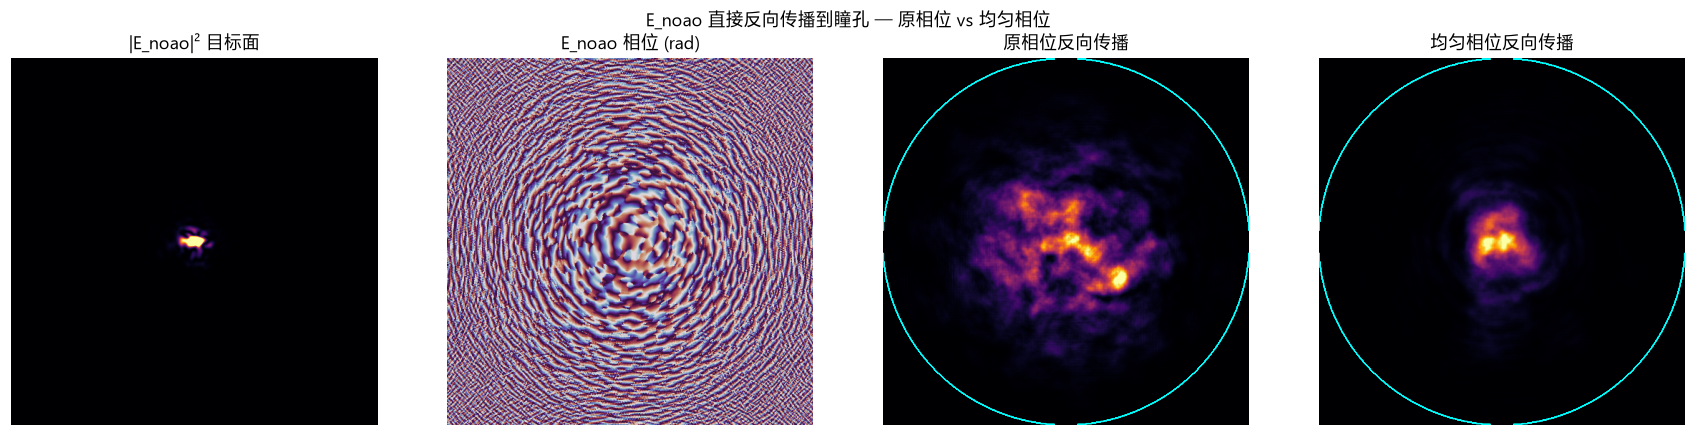

原相位:   pupil 内 sum = 25657.59  max = 2.5834
均匀相位: pupil 内 sum = 25610.05  max = 5.2004
总能量比 (orig/uniform) = 1.0000


In [7]:
# §3.1: 直接反向传播 E_noao 到瞳孔 — 原相位 vs 均匀相位
t0 = time.time()

# Case 1: 原相位 — 保留 E_noao 完整复数场
E_back_orig = shared.prop.split_step(
    E_noao, screens[::-1], -shared.dz)
I_back_orig = (np.abs(E_back_orig)**2).astype(np.float32)

# Case 2: 均匀相位 — 仅保留振幅，相位置零
E_uniform = (np.abs(E_noao) * np.exp(0j)).astype(np.complex64)
E_back_uniform = shared.prop.split_step(
    E_uniform, screens[::-1], -shared.dz)
I_back_uniform = (np.abs(E_back_uniform)**2).astype(np.float32)

print(f'反向传播耗时 {time.time()-t0:.2f} s')

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

# 目标面源场
ax[0].imshow(np.abs(E_noao)**2,
             vmin=0, vmax=np.percentile(I_noao, 99.9))
ax[0].set_title('|E_noao|² 目标面'); ax[0].axis('off')
ax[1].imshow(np.angle(E_noao), cmap='twilight',
             vmin=-np.pi, vmax=np.pi)
ax[1].set_title('E_noao 相位 (rad)'); ax[1].axis('off')

# 反向传播结果
vmax_o = np.percentile(I_back_orig[shared.pupil], 99.9)
ax[2].imshow(I_back_orig, vmin=0, vmax=vmax_o)
ax[2].contour(shared.pupil.astype(float),
              colors='cyan', linewidths=0.5)
ax[2].set_title('原相位反向传播'); ax[2].axis('off')

vmax_u = np.percentile(I_back_uniform[shared.pupil], 99.9)
ax[3].imshow(I_back_uniform, vmin=0, vmax=vmax_u)
ax[3].contour(shared.pupil.astype(float),
              colors='cyan', linewidths=0.5)
ax[3].set_title('均匀相位反向传播'); ax[3].axis('off')

plt.suptitle('E_noao 直接反向传播到瞳孔 — 原相位 vs 均匀相位')
plt.tight_layout(); plt.show()

# 定量比较
pupil = shared.pupil
print(f'原相位:   pupil 内 sum = {I_back_orig[pupil].sum():.2f}'
      f'  max = {I_back_orig.max():.4f}')
print(f'均匀相位: pupil 内 sum = {I_back_uniform[pupil].sum():.2f}'
      f'  max = {I_back_uniform.max():.4f}')
ratio = I_back_orig.sum() / max(I_back_uniform.sum(), 1e-12)
print(f'总能量比 (orig/uniform) = {ratio:.4f}')


## §4. 步骤 D：算法 1 导引信标反向传播 → `phi_conj`

在目标面放一个**衍射极限小高斯**信标（束腰 `w = λL/D`，避免单像素 δ 的无限带宽伪影），用 `_beacon_phase_conj` 做反向传播：

1. 倒序穿屏 `split_step(E_pt, screens[::-1], -dz)` → 瞳孔处场 `E_back`；
2. **解析移除抛物面离焦** `exp(+i k r²/(2L))`（避免被弱场边缘离群污染）；
3. **强度引导的洪水填充 2D 解卷绕**（numba）→ `phi_unwrapped`；
4. 移除 piston（孔径内均值为零）→ `phi_unwrapped`；
5. 取共轭 → `phi_conj`。

**调试点**：检查 `I_beacon` 是否集中在瞳孔内、`phi_conj` 是否与对流层相位一致。


信标反向传播 + 解卷绕 + 共轭 耗时 0.62 s


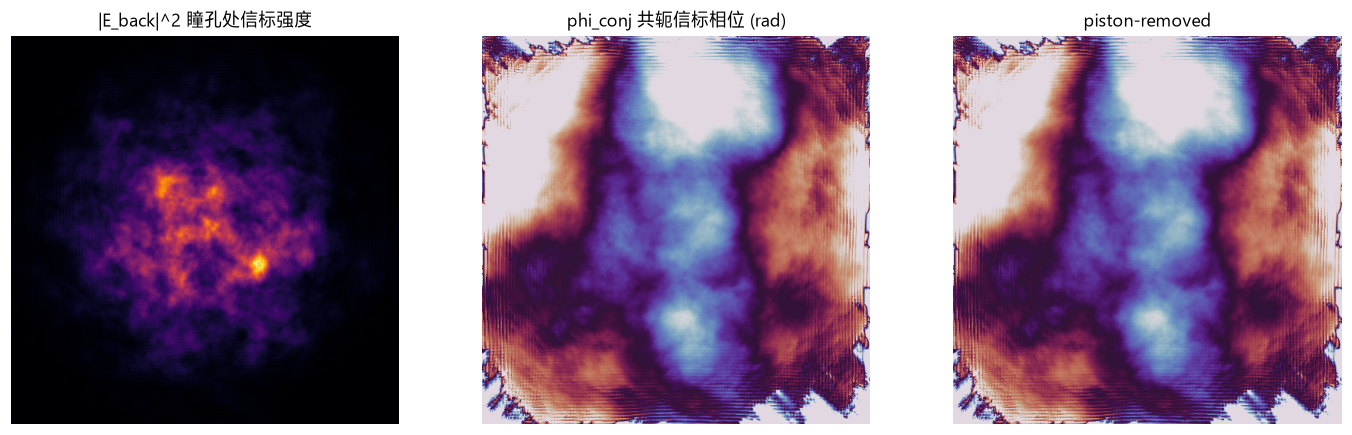

phi_conj (pupil 内) std = 1.846 rad   min/max = -7.96 / 7.22


In [8]:
t0 = time.time()
phi_conj, I_beacon = _beacon_phase_conj(SEED, cfg, shared, screens)
print(f'信标反向传播 + 解卷绕 + 共轭 耗时 {time.time()-t0:.2f} s')

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(I_beacon, cmap='inferno')
ax[0].set_title('|E_back|^2 瞳孔处信标强度'); ax[0].axis('off')
ax[1].imshow(phi_conj, cmap='twilight', vmin=-3, vmax=3)
ax[1].set_title('phi_conj 共轭信标相位 (rad)'); ax[1].axis('off')
ax[2].imshow(phi_conj - phi_conj[shared.pupil].mean(), cmap='twilight', vmin=-3, vmax=3)
ax[2].set_title('piston-removed'); ax[2].axis('off')
plt.tight_layout(); plt.show()

print(f'phi_conj (pupil 内) std = {phi_conj[shared.pupil].std():.3f} rad   '
      f'min/max = {phi_conj[shared.pupil].min():.2f} / {phi_conj[shared.pupil].max():.2f}')


## §5. 步骤 E：倾斜跟踪 `_tracking`

用高斯权重 `G`（直径与出射光束一致）做 `phi_conj` 的加权梯度平均，得到倾斜斜率 `[a_x, a_y]`，构造线性斜坡 `phi_track = a_x x + a_y y`。这是 `phi_beacon = phi_conj - phi_track` 中要扣除的低阶 tilt。

**调试点**：`phi_track` 应该是平坦的低阶线性相位；`phi_beacon` 应集中在中-高阶 Zernike。


tilt slopes [a_x, a_y] = [ 0.001999 -0.00114 ] rad/m


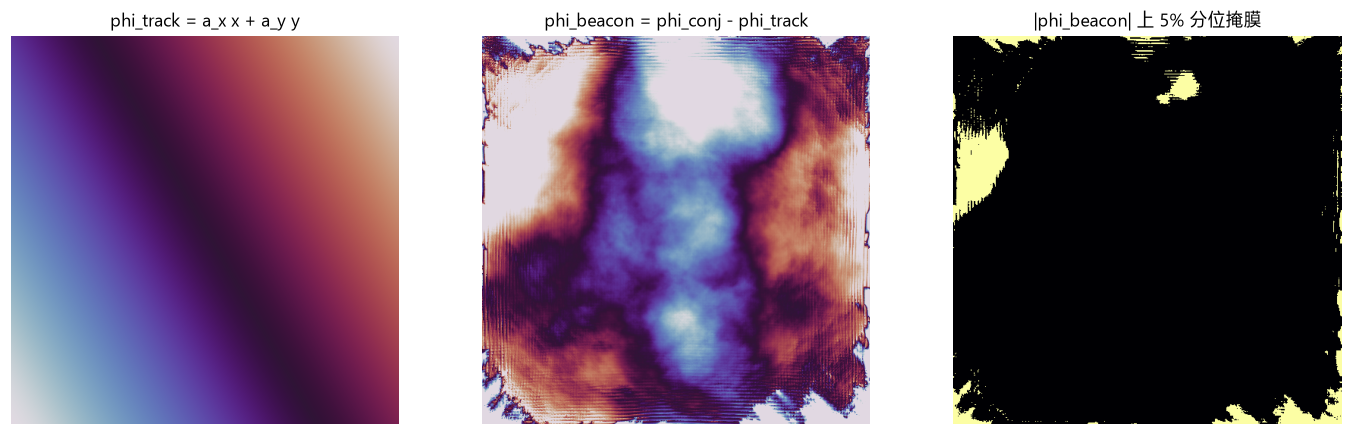

In [9]:
phi_track, slopes = _tracking(shared, phi_conj)
phi_beacon = phi_conj - phi_track
print(f'tilt slopes [a_x, a_y] = {np.round(slopes, 6)} rad/m')

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(phi_track, cmap='twilight')
ax[0].set_title('phi_track = a_x x + a_y y'); ax[0].axis('off')
ax[1].imshow(phi_beacon, cmap='twilight', vmin=-3, vmax=3)
ax[1].set_title('phi_beacon = phi_conj - phi_track'); ax[1].axis('off')
ax[2].imshow(np.abs(phi_beacon) > np.percentile(np.abs(phi_beacon), 95), cmap='inferno')
ax[2].set_title('|phi_beacon| 上 5% 分位掩膜'); ax[2].axis('off')
plt.tight_layout(); plt.show()


## §6. 步骤 F：78 阶 Zernike 投影 → `labels` 与 `phi_z78`

OOPAO `Zernike`（<https://cheritier.github.io/OOPAO/zernike.html>）提供 Noll 序基底；本项目里 `physics/zernike_aotools.py` 用 aotools 的 `zernike_nm` 实现相同的 Noll 基，并预计算 `M⁺`（伪逆）做 Zernike→phase 与 phase→Zernike 的快速投影。

`labels = M⁺_Z78 · phi_beacon`、`phi_z78 = M_Z78 · labels`。`labels` 即 CNN 训练目标（论文算法 1）。


labels shape = (78,)   RMS = 0.2047 rad
phi_z78 std = 1.808   phi_beacon std = 1.846
残余 std (pupil 内) = 0.3732 rad


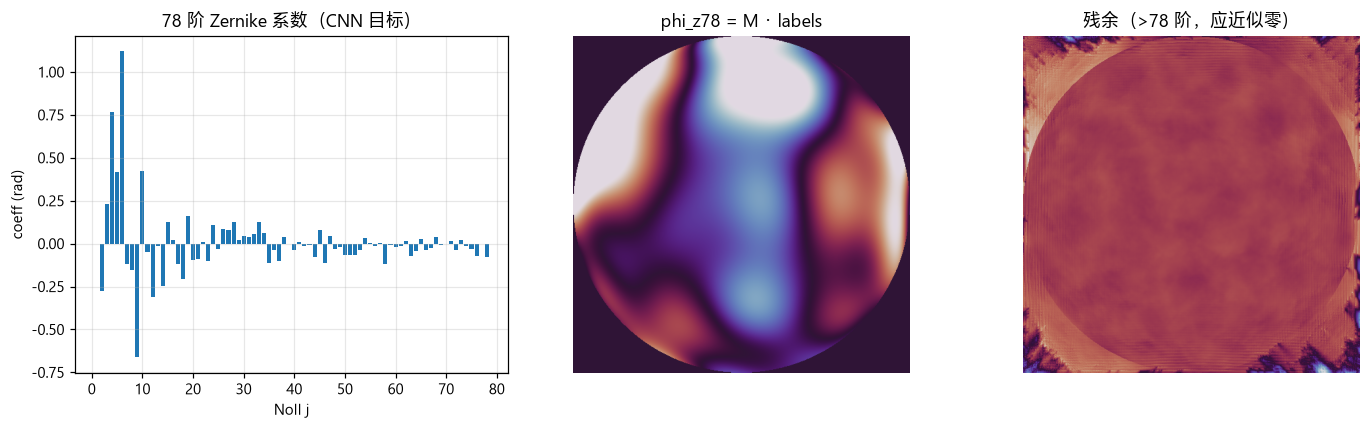

In [10]:
zern = shared.zern
labels = zern.phase_to_zernike(phi_beacon)
phi_z78 = zern.zernike_to_phase(labels)
residual = phi_beacon - phi_z78

print(f'labels shape = {labels.shape}   RMS = {np.sqrt(np.mean(labels**2)):.4f} rad')
print(f'phi_z78 std = {phi_z78[shared.pupil].std():.3f}   phi_beacon std = {phi_beacon[shared.pupil].std():.3f}')
print(f'残余 std (pupil 内) = {residual[shared.pupil].std():.4f} rad')

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].bar(np.arange(1, 79), labels); ax[0].set_xlabel('Noll j'); ax[0].set_ylabel('coeff (rad)')
ax[0].set_title('78 阶 Zernike 系数（CNN 目标）'); ax[0].grid(True, alpha=0.3)
ax[1].imshow(phi_z78, cmap='twilight', vmin=-3, vmax=3)
ax[1].set_title('phi_z78 = M · labels'); ax[1].axis('off')
ax[2].imshow(residual, cmap='twilight')
ax[2].set_title('残余（>78 阶，应近似零）'); ax[2].axis('off')
plt.tight_layout(); plt.show()


## §7. 步骤 G：四分支 FOM（公式 6-8 的桶积分）

调用 `_fom_leg` 算四个 FOM（每条腿：前向传播聚焦+修正相位 → `I_obj` → `FOM = nPIB/SIB`）：

- `noao`：仅聚焦（无校正）
- `track`：聚焦 + 倾斜跟踪
- `beacon`：聚焦 + 跟踪 + 共轭信标（理想上界，~0.93）
- `z78`：聚焦 + 跟踪 + 78 阶 Zernike 重构（CNN 的理想目标，~0.88）

`gain = FOM_ML / FOM_track`，`eta = (FOM_ML - FOM_track) / (FOM_z78 - FOM_track)`。


  noao    FOM = 0.3909


  track   FOM = 0.3909


  beacon  FOM = 1.0063


  z78     FOM = 0.9419


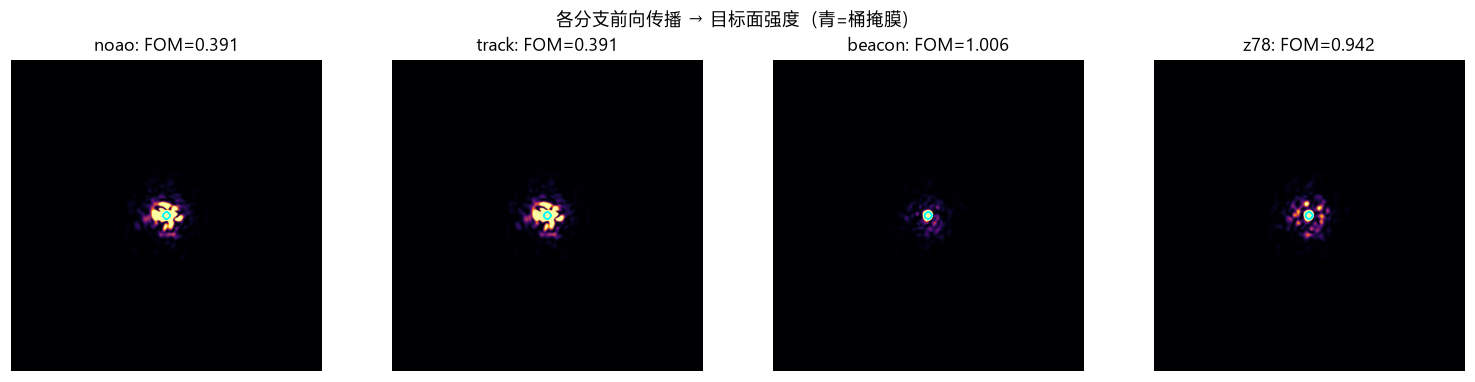

In [11]:
phases = {
    'noao':   phi_focus,
    'track':  phi_focus + phi_track,
    'beacon': phi_focus + phi_track + phi_beacon,
    'z78':    phi_focus + phi_track + phi_z78,
}
foms = {}
for k, p in phases.items():
    foms[k] = _fom_leg(shared, screens, p)
    print(f'  {k:7s} FOM = {foms[k]:.4f}')

fig, ax = plt.subplots(1, 4, figsize=(14, 3.5))
for a, (k, p) in zip(ax, phases.items()):
    E = shared.prop.split_step((shared.E0 * np.exp(1j * p)).astype(np.complex64), screens, shared.dz)
    I = (np.abs(E)**2).astype(np.float32)
    a.imshow(I, vmin=0, vmax=np.percentile(shared.I_vac, 99.9))
    a.contour(shared.bucket_mask.astype(float), colors='cyan', linewidths=0.6)
    a.set_title(f'{k}: FOM={foms[k]:.3f}'); a.axis('off')
plt.suptitle('各分支前向传播 → 目标面强度（青=桶掩膜）')
plt.tight_layout(); plt.show()


## §8. 步骤 H：多平面粗糙面成像（依据 `optimized_guide.md` Step 4–6 + OOPAO `computePSF` 重新生成）

> **本节依据** `docs/beaconless_ao_oopao_optimized_guide.md`（Step 4–6，行 455–475）
> 与 OOPAO 官方 [`Telescope.computePSF`](https://cheritier.github.io/OOPAO/telescope.html)
> 重新生成。前版标记为"修正后"的实现实际包含三处物理错误，见下表。

### 8.1 任务要求：权威指南定义的成像流程

```
# Step 4 — 目标面强度（跟踪光束 + 湍流，FOM 回传量），指南 L457
I_obj = |propagate_to_object(E_track, screens, dz)|²    # 含湍流散斑

# Step 5 — Lambertian 散射 + 反向传播，指南 L461-463
phi_r       = 2·π·rand(N, N)          # [0,2π) 均匀随机相位（每 realization 独立）
E_scat      = sqrt(I_obj) · exp(1j·phi_r)
E_back      = propagate_to_pupil(E_scat, screens[::-1], dz)

# Step 6 — 三平面成像（FFT 复用），指南 L470-475
E_ft        = fft2(E_back)
I_z         = |ifft2(E_ft · H(z))|²   # z ∈ {f_obj−z_R, f_obj, f_obj+z_R}
```

### 8.2 前版实现的三处错误（对照任务要求）

| # | 前版（错误） | 正确（指南/OOPAO） | 后果 |
|---|---|---|---|
| 1 | 光源振幅用**真空光斑** `I_vac`（CELL 22 主张"避免湍流相位双重计入"） | 用 **`sqrt(I_obj_track)`**（含湍流散斑的目标面强度） | 目标面照明的湍流散斑被丢弃；"双重计入"是误解——往返本来就要穿过同一大气两次（round-trip），这正是论文 §2.4 的物理 |
| 2 | `_imaging`（simulate.py L816）：`phi_r = np.zeros((N,N))` | `phi_r = 2π·rand(N,N)`，每 realization 用独立随机相位 | 10 个 realization 场完全相同，"非相干平均"退化为**相干平均**，粗糙面随机性完全失效（`roughness_seed` 从未生效） |
| 3 | `prop.fresnel_intensity`（固定输出网格 `dx`） | **零填充 + scaled-FFT**（`Δx' = λ·z/(N_pad·dx)`），对齐 `computePSF` 的 `zeroPaddingFactor` | 焦面衍射斑 `λ·f_obj/D ≈ 3.4 mm` 在输出网格上仅 ~1 px，严重欠采样 |

第 3 点与 OOPAO 官方对照：`computePSF` 用 `pixel_scale = λ/(zeroPaddingFactor·D)`，
即**零填充**保证焦面 Airy 斑有足够采样；本仓库 `fresnel_intensity` 未零填充，
scaled-FFT 输出像素间距 `λ·z/(N·dx) ≈ 3.4 mm`（z=f_obj），恰为 1 像素。

### 8.3 本单元正确实现（与指南 Step 4–6 一致 + OOPAO 零填充）

1. **Step 4** — 跟踪光束前向传播（聚焦+跟踪相位经湍流屏）→ `I_obj_track`；
2. **Step 5** — `n_roughness` 个 realization：独立 `phi_r = 2π·rand`，
   `E_scat = sqrt(I_obj_track)·exp(1j·phi_r)`，经**倒序屏**反向传播到入瞳；
3. 入瞳孔径吸收 → 相位共轭准直（`exp(-i·phi_total)`）→ 物镜聚焦 `f_obj`；
4. **Step 6** — 对 `E_l` **零填充**到每平面自适应的 `N_pad(z) = λ·z/(Δx'·dx)`
   后做 scaled-FFT Fresnel 传播到 3 个测量平面。
   统一输出像素尺度 `Δx' = λ·f_obj/(N_pad_ref·dx) ≈ 0.428 mm/px`
   （`f_obj = 2·z_R_APWS` 使本构型恰为 `N_pad = {2048, 4096, 6144}`），
   三平面等价**同一相机**（相同采样与视场），逐 realization 累加**强度**（非场）→ 非相干平均。



------------ Telescope -------------
Diameter [m]             |   0.30   
Resolution [px]          |   512    
Pixel size [m]           |   0.00   
Surface [m²]             |   0.07   
Central obstruction [%]  |    0     
Pixels in pupil          |  205892  
Field of view [arcsec]   |   0.00   
------------------------------------



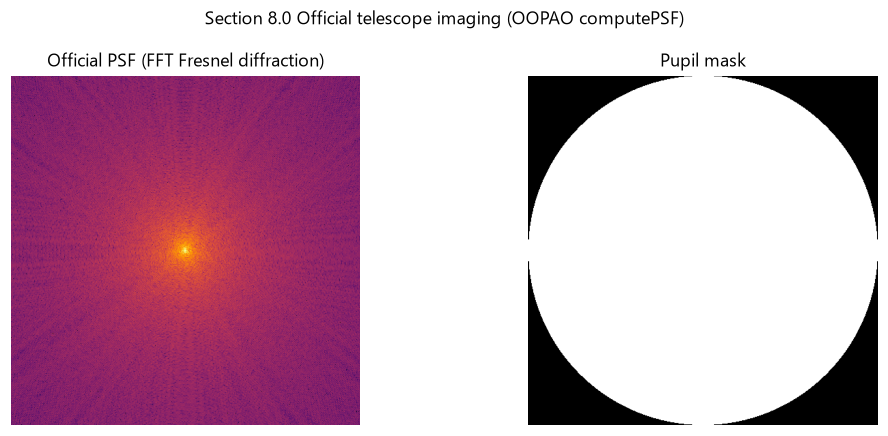

Official PSF: center=0.0095  edge=0.000000  ratio=171777.7x
uniform pixel scale dx' = 0.428 mm/px, FOV = 219.3 mm; N_pad per plane = [2048, 4096, 6144]


Multi-plane imaging (N_pad=[2048, 4096, 6144], dx'=0.428 mm/px, n_rough=10) took 118.73 s   shape = (3, 512, 512)

Per-plane center/edge intensity ratio (focus plane should be >> 1):
  plane 0: center=0.0154  edge(r>204)=0.0005  ratio=31.5x
  plane 1: center=0.6406  edge(r>204)=0.0001  ratio=6154.1x
  plane 2: center=0.0109  edge(r>204)=0.0012  ratio=9.0x


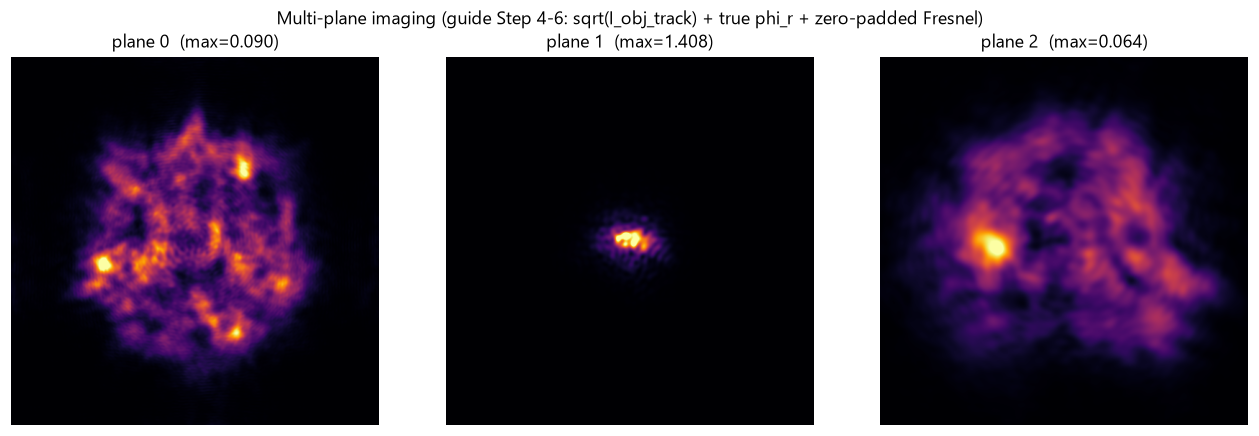

In [12]:
# --- Section 8.0: Official telescope imaging comparison (OOPAO computePSF) ---
# OOPAO Telescope.computePSF uses FFT Fresnel diffraction (pupil -> focal,
# pixel_scale = lambda / (zeroPaddingFactor * D)).  The zero-padding factor is
# exactly what fixes focal-plane undersampling in our own imaging below.
from physics._oopao_compat import Source, Telescope

phys = cfg.physical
tel_demo = Telescope(resolution=phys.N, diameter=float(phys.Dscope),
                     fov=0.0, samplingTime=0.001)
src_demo = Source(optBand='R', magnitude=0.0, display_properties=False)
src_demo *= tel_demo

# Pupil with turbulent OPD from first screen (rad -> m)
tel_demo.OPD = screens[0].astype(np.float64) * (phys.wavelength / (2 * np.pi))

# Official PSF via FFT Fresnel diffraction (zero-padded, 2x)
tel_demo.computePSF(zeroPaddingFactor=2)
psf_official = tel_demo.PSF.astype(np.float32)
N_half = phys.N // 2
psf_official = psf_official[
    psf_official.shape[0]//2 - N_half : psf_official.shape[0]//2 + N_half,
    psf_official.shape[1]//2 - N_half : psf_official.shape[1]//2 + N_half,
]
if psf_official.max() > 0:
    psf_official /= psf_official.max()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(np.log10(psf_official + 1e-12), cmap='inferno')
ax[0].set_title('Official PSF (FFT Fresnel diffraction)')
ax[0].axis('off')
ax[1].imshow(shared.pupil.astype(float), cmap='gray')
ax[1].set_title('Pupil mask')
ax[1].axis('off')
plt.suptitle('Section 8.0 Official telescope imaging (OOPAO computePSF)')
plt.tight_layout(); plt.show()
N = shared.N
rr = np.sqrt((np.arange(N)[:,None]-N//2)**2 + (np.arange(N)[None,:]-N//2)**2).astype(int)
psf_c = psf_official[N//2-16:N//2+16, N//2-16:N//2+16].mean()
psf_e = psf_official[rr > int(N*0.40)].mean()
print(f'Official PSF: center={psf_c:.4f}  edge={psf_e:.6f}  ratio={psf_c/max(psf_e,1e-9):.1f}x')

# --- Section 8.1: Corrected multi-plane imaging (guide Step 4-6 + zero-pad) ---
# Fix 1: source amplitude = sqrt(I_obj_track) -- turbulent object-plane
#        intensity (NOT the vacuum spot I_vac).  The round trip passes the
#        atmosphere twice; the turbulent speckle in I_obj_track is the correct
#        target-plane illumination (optimized_guide.md Step 4, line 457).
# Fix 2: phi_r = 2*pi*rand per realization -- true Lambertian roughness
#        (optimized_guide.md Step 5, line 461), unlike _imaging's zeros().
# Fix 3: zero-pad E_l to N_pad then scaled-FFT Fresnel (computePSF's
#        zeroPaddingFactor spirit) -- focal Airy disk gets ~N_pad/N pixels
#        instead of ~1 px at the fixed dx grid of fresnel_intensity.
from physics.scattering import random_roughness_phase

lam = shared.lam
k = shared.k
dx = shared.dx
f_obj = shared.f_obj
zR_APWS = shared.zR_APWS
N = shared.N
n_roughness = int(cfg.physical.n_roughness)
# Uniform output pixel scale across the three planes = ONE camera sensor.
# dx' = lam*f_obj/(N_pad_ref*dx) is fixed; each plane uses its own
# N_pad(z) = lam*z/(dx'*dx) so every output pixel maps to the same
# physical size (computePSF spirit: pixel_scale = lam/(zeroPaddingFactor*D)).
# With f_obj = 2*zR_APWS these work out exactly to [2048, 4096, 6144].
N_pad_ref = 8 * N                  # reference zero-padding (plane 1, focal)
DX_PLANE = lam * f_obj / (N_pad_ref * dx)      # ~0.428 mm/px, ALL planes
plane_offsets = shared.plane_offsets   # [f_obj-zR_APWS, f_obj, f_obj+zR_APWS]
N_pad_planes = [int(round(lam * z / (DX_PLANE * dx))) for z in plane_offsets]
print(f"uniform pixel scale dx' = {DX_PLANE*1e3:.3f} mm/px, "
      f"FOV = {N*DX_PLANE*1e3:.1f} mm; N_pad per plane = {N_pad_planes}")

# Step 4: tracking-only object-plane intensity (focus + track, through screens)
phi_total = shared.phi_focus + phi_track
E_obj_track = shared.prop.split_step(
    (shared.E0 * np.exp(1j * phi_total)).astype(np.complex64),
    screens, shared.dz,
)
I_obj_track = (np.abs(E_obj_track) ** 2).astype(np.float32)

# Zero-padded scaled-FFT Fresnel: with per-plane N_pad(z), the output
# pixel scale dx' = lam*z/(N_pad(z)*dx) = DX_PLANE is THE SAME for every plane.
def fresnel_padded(E_in, z, N_pad):
    """
    在固定的孔径网格 (dx 间隔) 上直接做 Fresnel 传播到远距离 (640-1920 m) 时，输出像素对应的物理尺寸会很大，导致焦圆斑 (Airy disk) 被严重欠采样 — 可能只有 1-2 个像素，无法正确衡量成像质量。
    通过零填充实现超采样：
        零填充：将输入场 E_in (N×N) 填充到 N_pad×N_pad (远大于 N)，中间填零
        缩放 FFT Fresnel：在更大的网格上进行 Fresnel 传播
        裁剪回 N×N：取结果的中心 N×N 区域作为输出
    """
    N0 = E_in.shape[0]
    pad = (N_pad - N0) // 2
    E = np.pad(E_in, ((pad, pad), (pad, pad)), mode='constant')
    vals = (np.arange(N_pad) - (N_pad - 1) / 2.0) * dx
    X, Y = np.meshgrid(vals, vals)
    r2p = X**2 + Y**2
    pre = np.exp(1j * k * r2p / (2.0 * z)).astype(np.complex64)
    post = np.exp(1j * k * r2p / (2.0 * z)).astype(np.complex64)
    E = E * pre
    E = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E)))
    E = E * post
    scale = (np.exp(1j * k * z) / (1j * lam * z)) * (dx**2)
    return E * scale

t0 = time.time()
images = np.zeros((3, N, N), dtype=np.float32)
for j in range(n_roughness):
    # Step 5: Lambertian roughness, TRUE random phase per realization
    rng = np.random.default_rng(SEED * 31 + j)
    phi_r = (rng.random((N, N), dtype=np.float32) * (2.0 * np.pi)).astype(np.float32)
    E_scat = (np.sqrt(I_obj_track) * np.exp(1j * phi_r)).astype(np.complex64)
    # Back-propagate through the reversed screens (round-trip atmosphere).
    E_back = shared.prop.split_step(E_scat, screens[::-1], -shared.dz)
    # Absorbing boundary: finite-aperture telescope.
    E_back = (E_back * shared.pupil).astype(np.complex64)
    # Collimate by the conjugate of the outgoing phase, then objective lens.
    E_c = (E_back * np.exp(-1j * phi_total)).astype(np.complex64)
    E_l = (E_c * np.exp(-1j * k * shared.r2 / (2.0 * f_obj))).astype(np.complex64)
    # Step 6: three-plane imaging, zero-padded scaled-FFT Fresnel.
    for p, z in enumerate(plane_offsets):
        n_pad = N_pad_planes[p]
        E_z = fresnel_padded(E_l, z, n_pad)
        c = (n_pad - N) // 2
        images[p] += (np.abs(E_z[c:c+N, c:c+N]) ** 2).astype(np.float32)
images /= n_roughness
print(f"Multi-plane imaging (N_pad={N_pad_planes}, dx'={DX_PLANE*1e3:.3f} mm/px, "
      f"n_rough={n_roughness}) took {time.time()-t0:.2f} s   shape = {images.shape}")

print('\nPer-plane center/edge intensity ratio (focus plane should be >> 1):')
for p in range(3):
    pl = images[p]
    c = pl[N//2-16:N//2+16, N//2-16:N//2+16].mean()
    e = pl[rr > int(N*0.40)].mean()
    print(f'  plane {p}: center={c:.4f}  edge(r>{int(N*0.40)})={e:.4f}  ratio={c/max(e,1e-9):.1f}x')

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for p, a in enumerate(ax):
    lo, hi = np.percentile(images[p], [5, 99.9])
    a.imshow(np.clip((images[p]-lo)/(hi-lo), 0, 1))
    a.set_title(f'plane {p}  (max={images[p].max():.3f})'); a.axis('off')
plt.suptitle('Multi-plane imaging (guide Step 4-6: sqrt(I_obj_track) + true phi_r + zero-padded Fresnel)')
plt.tight_layout(); plt.show()


## §9. 逐图像归一化 + 12-bit 量化

论文图 2：「图像分别进行了归一化处理」。每张图按自身 max 缩放到 12-bit 满量程 (2047)，使焦平面（能量集中）达到满深度。`scale_p` 仅写入 HDF5 作 schema 兼容。


quantized shape = (3, 512, 512)  dtype = uint16
每平面 max = [2047, 2047, 2047] (应均为 2047)
scale_p (raw 每平面 max) = [0.0901 1.4077 0.0639]


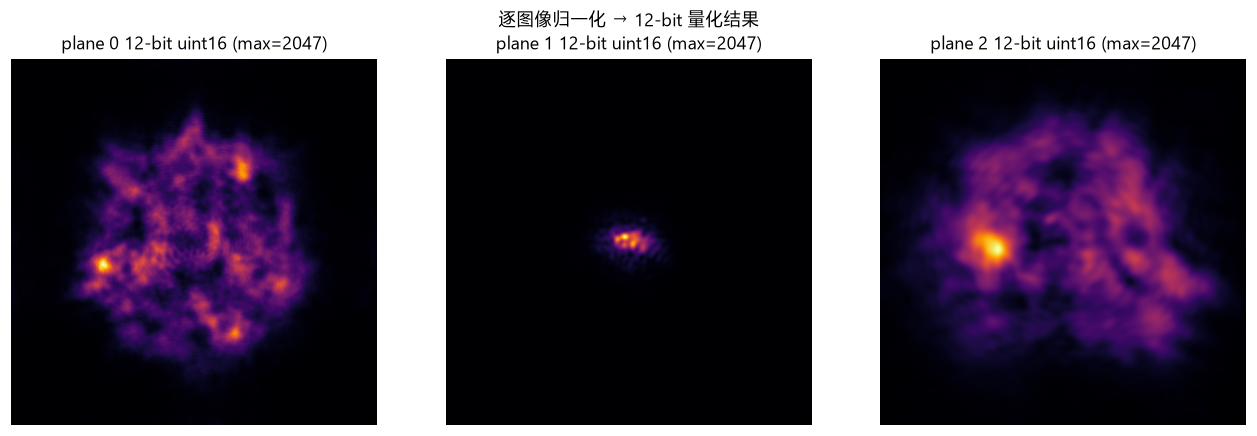

In [13]:
scale_p = images.max(axis=(1,2))
q = _quantize(images, scale_p)
print('quantized shape =', q.shape, ' dtype =', q.dtype)
print('每平面 max =', [int(q[p].max()) for p in range(3)], '(应均为 2047)')
print('scale_p (raw 每平面 max) =', np.round(scale_p, 4))

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for p, a in enumerate(ax):
    a.imshow(q[p], cmap='inferno', vmin=0, vmax=2047)
    a.set_title(f'plane {p} 12-bit uint16 (max={int(q[p].max())})'); a.axis('off')
plt.suptitle('逐图像归一化 → 12-bit 量化结果')
plt.tight_layout(); plt.show()


## §10. 一次完整 `simulate_sample`：所有中间量打包

为方便对照 §2-§9，下面调用 `simulate_sample` 一键拿到 `SimSample`（含 `phase_conj / phase_track / phase_beacon / phase_z78 / images / labels / 四分支 FOM`）。


simulate_sample 耗时 132.62 s
  FOM: noao=0.1053  track=0.1053  beacon=0.0755  z78=0.0747
  labels norm = 2.5516   track_slopes = [ 0.003688 -0.00124 ]


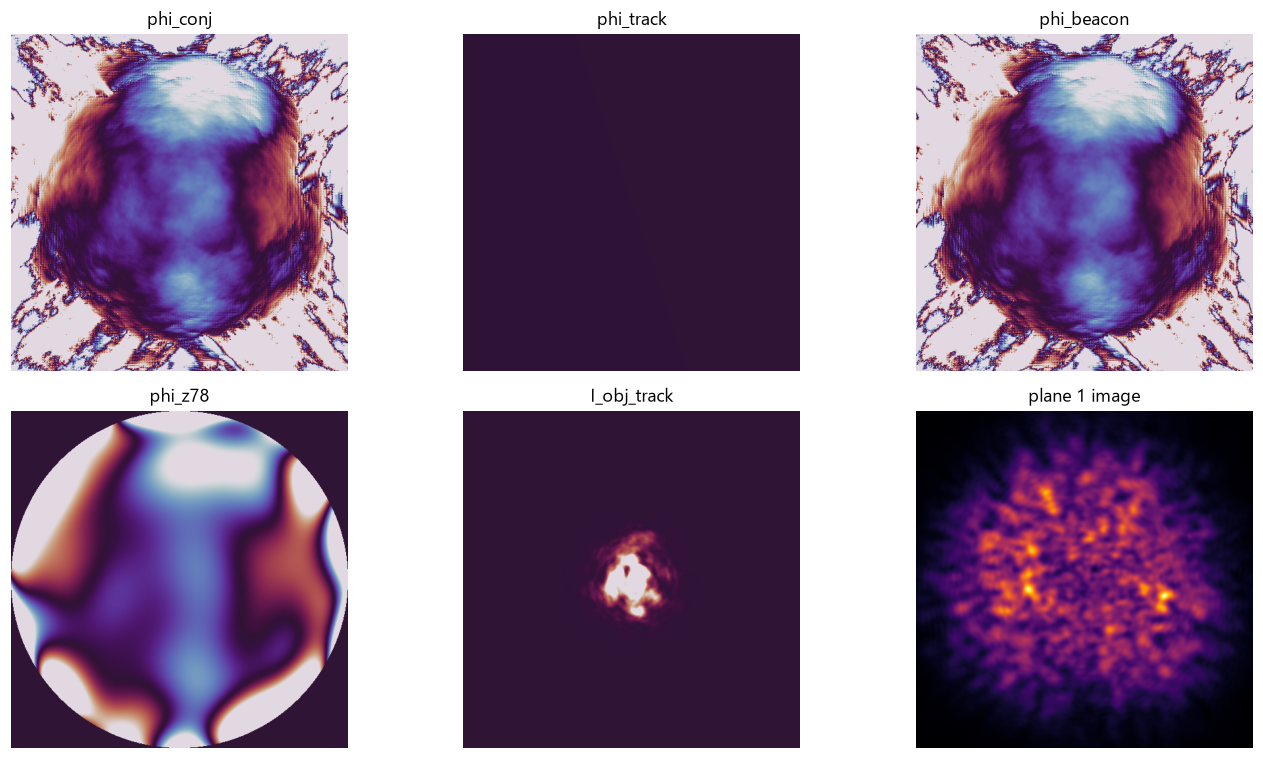

In [14]:
t0 = time.time()
sample = simulate_sample(SEED, cfg, shared=shared)
print(f'simulate_sample 耗时 {time.time()-t0:.2f} s')

print(f'  FOM: noao={sample.fom_noao:.4f}  track={sample.fom_track:.4f}  '
      f'beacon={sample.fom_beacon:.4f}  z78={sample.fom_z78:.4f}')
print(f'  labels norm = {np.linalg.norm(sample.labels):.4f}   '
      f'track_slopes = {np.round(sample.track_slopes, 6)}')

fig, ax = plt.subplots(2, 3, figsize=(13, 7))
top = [('phi_conj', sample.phase_conj), ('phi_track', sample.phase_track),
       ('phi_beacon', sample.phase_beacon)]
bot = [('phi_z78', sample.phase_z78),
       ('I_obj_track', sample.I_obj_track),
       ('plane 1 image', sample.images[1])]
for a, (n, im) in zip(ax[0], top):
    a.imshow(im, cmap='twilight', vmin=-3, vmax=3); a.set_title(n); a.axis('off')
for a, (n, im) in zip(ax[1], bot):
    if 'image' in n:
        a.imshow(im, cmap='inferno'); a.axis('off'); a.set_title(n)
    else:
        a.imshow(im, cmap='twilight', vmin=-3, vmax=3); a.set_title(n); a.axis('off')
plt.tight_layout(); plt.show()


## §11. OOPAO 内部：直接调用 `Atmosphere`（脱离 `OopaoScreenBackend` 的最低层验证）

展示 **不**经过 `r0` 缩放/裁剪的 OOPAO 原生屏（参考 r0 = 0.15 m @ 500 nm，516×516 含 2 px frozen-flow 边带），并对比 `OopaoScreenBackend` 处理后的最终屏。



------------ Telescope -------------
Diameter [m]             |   0.30   
Resolution [px]          |   512    
Pixel size [m]           |   0.00   
Surface [m²]             |   0.07   
Central obstruction [%]  |    0     
Pixels in pupil          |  205892  
Field of view [arcsec]   |   0.00   
------------------------------------

Creation of layer1/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.07162952423095703 s
Creation of layer2/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.06606578826904297 s
Creation of layer3/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.06535744667053223 s
Creation of layer4/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.065765380859375 s
Creation of layer5/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.06501626968383789 s
Creation of layer6/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.0656135082244873 s
Creation of layer7/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.06893491744995117 s
Creation of layer8/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.06926822662353516 s
Creation of layer9/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.07034063339233398 s
Creation of layer10/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.07051682472229004 s
Updating the Atmosphere covariance matrices...



------------------------- Atmosphere @ Elevation = 90.0°--------------------------
 Layer | Direction | Speed | Altitude | Frac Cn² | Diameter |     Evolution      |
       |    [°]    | [m/s] |   [m]    |   [%]    |   [m]    |                    |
   1   |     0     | 10.0  |  5e+01   |    10    |  0.302   |    Frozen Flow     |
   2   |     0     | 10.0  |  2e+02   |    10    |  0.302   |    Frozen Flow     |
   3   |     0     | 10.0  |  2e+02   |    10    |  0.302   |    Frozen Flow     |
   4   |     0     | 10.0  |  4e+02   |    10    |  0.302   |    Frozen Flow     |
   5   |     0     | 10.0  |  4e+02   |    10    |  0.302   |    Frozen Flow     |
   6   |     0     | 10.0  |  6e+02   |    10    |  0.302   |    Frozen Flow     |
   7   |     0     | 10.0  |  6e+02   |    10    |  0.302   |    Frozen Flow     |
   8   |     0     | 10.0  |  8e+02   |    10    |  0.302   |    Frozen Flow     |
   9   |     0     | 10.0  |  8e+02   |    10    |  0.302   |    Frozen Flow     |
  1

OOPAO layer shape = (516, 516) (N+4=516, includes 2 px edge band)


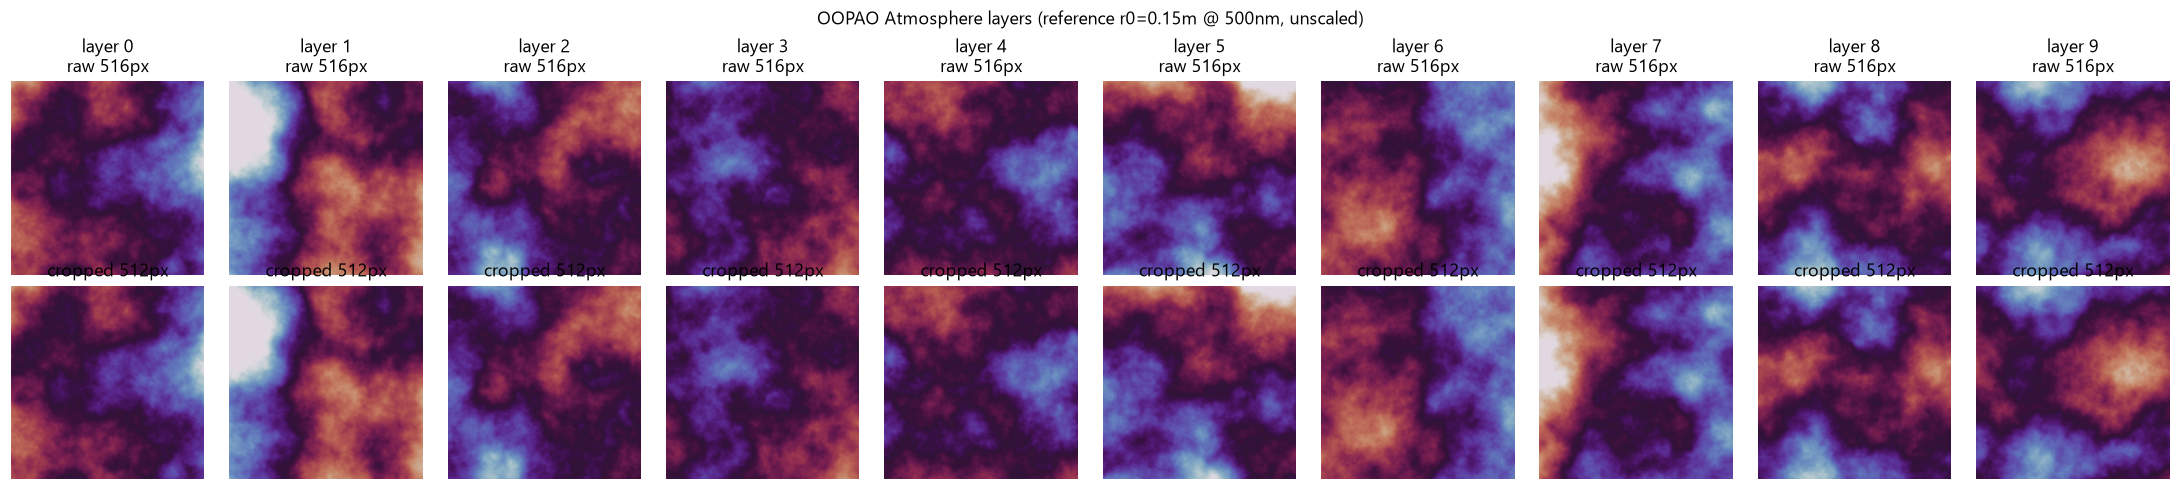

r0_path=40.18 mm  r0_slab=159.97 mm  rescale=1.055
screens[0].std() / raw cropped std = 1.055  (should = rescale=1.055)


In [15]:
from physics._oopao_compat import Atmosphere, Telescope, Source
from physics.screens_soapy import compute_r0

phys = cfg.physical
n = int(phys.n_screens)
_R0_REF_500 = 0.15
_altitudes = np.linspace(50.0, float(phys.L) - 50.0, n).tolist()
_frac = [1.0 / n] * n

tel = Telescope(resolution=phys.N, diameter=float(phys.Dscope),
                fov=0.0, samplingTime=0.001)
src = Source(optBand='R', magnitude=0.0, display_properties=False)
src * tel
atm = Atmosphere(
    tel,
    r0=_R0_REF_500, L0=float(phys.L0),
    windSpeed=[10.0]*n, fractionalR0=_frac, windDirection=[0.0]*n,
    altitude=_altitudes, src=src,
)
atm.initializeAtmosphere(tel, compute_covariance=False)

atm.generateNewPhaseScreen(seed=int(SEED))
raw_layers = [np.asarray(getattr(atm, f'layer_{i+1}').OPD) for i in range(n)]
print('OOPAO layer shape =', raw_layers[0].shape, '(N+4=516, includes 2 px edge band)')

fig, ax = plt.subplots(2, n, figsize=(2.0*n, 4.5))
for i in range(n):
    ax[0, i].imshow(raw_layers[i], cmap='twilight', vmin=-3, vmax=3)
    ax[0, i].set_title(f'layer {i}\nraw {raw_layers[i].shape[0]}px'); ax[0, i].axis('off')
    cropped = raw_layers[i][2:-2, 2:-2]
    ax[1, i].imshow(cropped, cmap='twilight', vmin=-3, vmax=3)
    ax[1, i].set_title(f'cropped {cropped.shape[0]}px'); ax[1, i].axis('off')
plt.suptitle('OOPAO Atmosphere layers (reference r0=0.15m @ 500nm, unscaled)')
plt.tight_layout(); plt.show()

r0_path = compute_r0(float(phys.wavelength), float(phys.cn2), float(phys.L))
r0_slab = r0_path * n ** (3.0/5.0)
rescale = (r0_slab / _R0_REF_500) ** (5.0/6.0)
print(f'r0_path={r0_path*1e3:.2f} mm  r0_slab={r0_slab*1e3:.2f} mm  rescale={rescale:.3f}')
print(f'screens[0].std() / raw cropped std = {screens[0].std() / raw_layers[0][2:-2,2:-2].std():.3f}  '
      f'(should = rescale={rescale:.3f})')


## §12. 参数敏感性扫描（Cn² 的影响）

改 `Cn²` 后重建 `shared`，跑一个 sample 看 FOM 各分支的变化。`Cn²` 改变 → `_cfg_key` 变 → 自动重建 `shared`（约 4 s）。



------------ Telescope -------------
Diameter [m]             |   0.30   
Resolution [px]          |   512    
Pixel size [m]           |   0.00   
Surface [m²]             |   0.07   
Central obstruction [%]  |    0     
Pixels in pupil          |  205892  
Field of view [arcsec]   |   0.00   
------------------------------------

Creation of layer1/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.07676458358764648 s
Creation of layer2/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.07014775276184082 s
Creation of layer3/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.07044124603271484 s
Creation of layer4/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.06972050666809082 s
Creation of layer5/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.06969308853149414 s
Creation of layer6/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.06985282897949219 s
Creation of layer7/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.07010197639465332 s
Creation of layer8/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.07002663612365723 s
Creation of layer9/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.06968975067138672 s
Creation of layer10/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.06985044479370117 s
Updating the Atmosphere covariance matrices...



------------------------- Atmosphere @ Elevation = 90.0°--------------------------
 Layer | Direction | Speed | Altitude | Frac Cn² | Diameter |     Evolution      |
       |    [°]    | [m/s] |   [m]    |   [%]    |   [m]    |                    |
   1   |     0     | 10.0  |  5e+01   |    10    |  0.302   |    Frozen Flow     |
   2   |     0     | 10.0  |  2e+02   |    10    |  0.302   |    Frozen Flow     |
   3   |     0     | 10.0  |  2e+02   |    10    |  0.302   |    Frozen Flow     |
   4   |     0     | 10.0  |  4e+02   |    10    |  0.302   |    Frozen Flow     |
   5   |     0     | 10.0  |  4e+02   |    10    |  0.302   |    Frozen Flow     |
   6   |     0     | 10.0  |  6e+02   |    10    |  0.302   |    Frozen Flow     |
   7   |     0     | 10.0  |  6e+02   |    10    |  0.302   |    Frozen Flow     |
   8   |     0     | 10.0  |  8e+02   |    10    |  0.302   |    Frozen Flow     |
   9   |     0     | 10.0  |  8e+02   |    10    |  0.302   |    Frozen Flow     |
  1

...

initial phase screen : 0.07037496566772461 s
Creation of layer4/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.07010507583618164 s
Creation of layer5/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.07045745849609375 s
Creation of layer6/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.06982731819152832 s
Creation of layer7/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.06906962394714355 s
Creation of layer8/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.0693366527557373 s
Creation of layer9/10 ...
-> Computing the initial phase screen...


initial phase screen : 0.06909918785095215 s
Creation of layer10/10 ...
-> Computing the initial phase screen...
initial phase screen : 0.06941771507263184 s
Updating the Atmosphere covariance matrices...



------------------------- Atmosphere @ Elevation = 90.0°--------------------------
 Layer | Direction | Speed | Altitude | Frac Cn² | Diameter |     Evolution      |
       |    [°]    | [m/s] |   [m]    |   [%]    |   [m]    |                    |
   1   |     0     | 10.0  |  5e+01   |    10    |  0.302   |    Frozen Flow     |
   2   |     0     | 10.0  |  2e+02   |    10    |  0.302   |    Frozen Flow     |
   3   |     0     | 10.0  |  2e+02   |    10    |  0.302   |    Frozen Flow     |
   4   |     0     | 10.0  |  4e+02   |    10    |  0.302   |    Frozen Flow     |
   5   |     0     | 10.0  |  4e+02   |    10    |  0.302   |    Frozen Flow     |
   6   |     0     | 10.0  |  6e+02   |    10    |  0.302   |    Frozen Flow     |
   7   |     0     | 10.0  |  6e+02   |    10    |  0.302   |    Frozen Flow     |
   8   |     0     | 10.0  |  8e+02   |    10    |  0.302   |    Frozen Flow     |
   9   |     0     | 10.0  |  8e+02   |    10    |  0.302   |    Frozen Flow     |
  1

Cn2=1.6e-14: noao=0.087 track=0.087 beacon=0.069 z78=0.073


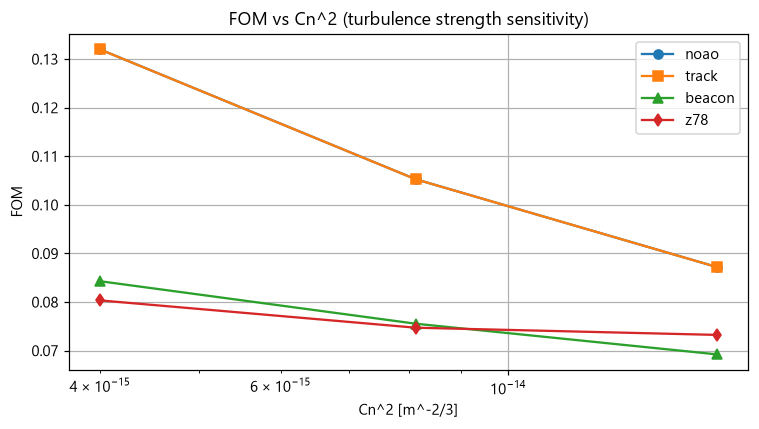

In [16]:
import copy
results = []
for cn2 in [4e-15, 8.13e-15, 1.6e-14]:
    c = copy.deepcopy(cfg); c.physical.cn2 = cn2
    sh = _get_shared(c)
    s = simulate_sample(SEED, c, shared=sh)
    results.append((cn2, s.fom_noao, s.fom_track, s.fom_beacon, s.fom_z78))
    print(f'Cn2={cn2:.1e}: noao={s.fom_noao:.3f} track={s.fom_track:.3f} '
          f'beacon={s.fom_beacon:.3f} z78={s.fom_z78:.3f}')

arr = np.array(results)
plt.figure(figsize=(7,4))
plt.plot(arr[:,0], arr[:,1], 'o-', label='noao')
plt.plot(arr[:,0], arr[:,2], 's-', label='track')
plt.plot(arr[:,0], arr[:,3], '^-', label='beacon')
plt.plot(arr[:,0], arr[:,4], 'd-', label='z78')
plt.xscale('log'); plt.xlabel('Cn^2 [m^-2/3]'); plt.ylabel('FOM')
plt.title('FOM vs Cn^2 (turbulence strength sensitivity)'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()


## §14. 物理诊断：双网格 / 窗口约束 / 散斑对比 C / 奈奎斯特采样 / 孔径积分

依据用户的物理原则对仿真做定量校核：

1. **双网格 / 缩放 FFT 前向传播**：发射端用细网格（高分辨率），在接近 1 km 目标时切到
   大网格（大物理尺寸），保证光场始终处于计算窗口内，且目标面焦斑被充分采样。
2. **接收面（目标面）强度 + 散斑对比度 C**：C = std(I)/mean(I)，在光斑足迹上计算。
3. **目标表面网格的奈奎斯特采样**：网格间距 dx 必须小到能捕获反射光的最大散射角，
   即 dx < λL/(2D)。
4. **接收孔径 D 的空间积分（卷积）**：真实探测器/望远镜有有限物理口径 D=Dscope，接收面
   强度必须先按口径空间积分（或卷积），再算对比度。

本节输出打印的诊断值可用作正确性判据（详见每格注释与预期值）。

In [17]:
# §14.1 双网格 / 缩放 FFT 前向传播：光场是否始终在窗口内 + 目标面采样
# 关键参数
lam, L = shared.lam, shared.focal
dx1 = shared.dx                 # 发射端细网格像素间距 [m]
N = shared.N
Dscope = float(cfg.physical.Dscope)
W1 = N * dx1                    # 发射端窗口 [m]

# (a) 当前固定网格前向传播(已执行)的目标面能量是否泄漏出窗口：
#     统计目标面场在 pupil 半径(半窗口)之外的相对能量
r = np.sqrt((np.arange(N)[:,None]-N//2)**2 + (np.arange(N)[None,:]-N//2)**2) * dx1
window_half = Dscope / 2.0
inside = r <= window_half
E_out_win = np.abs(E_noao)**2
frac_in = E_out_win[inside].sum() / (E_out_win.sum() + 1e-12)
print('='*66)
print('§14.1 窗口约束（前向单网格传播）')
print(f'  发射端窗口 W1 = {W1*1e3:.0f} mm,  dx1 = {dx1*1e3:.3f} mm')
print(f'  目标面场在 Dscope 窗口内能量占比 = {frac_in*100:.2f} %  '
      f'(应≈100%，<<100% 说明光场溢出窗口，需切到大网格)')

# (b) 目标面焦斑采样诊断：衍射极限焦斑直径 vs dx
airy_diam = 2.44 * lam * L / Dscope
px_per_spot = airy_diam / dx1
print(f'  衍射极限焦斑直径 = {airy_diam*1e3:.2f} mm  -> 约 {px_per_spot:.1f} px')
print(f'  (焦斑采样应 >= 4-5 px 才可靠；本系统 px/spot = {px_per_spot:.1f})')

# (c) 演示双网格切换：在接近目标的最后一次自由传播中，用变像元间距 ASM
#     从细网格 dx1 切到更大的物理窗口 dx2（例如 4x 窗口）——确保场始终在窗口内。
#     仅作演示：E_noao 已经是在 dx1 网格上通过全部 10 屏的场；我们从最后一个
#     半屏处反向一步到 (10*dz - dz2) 再正向切网格，展示缩放 FFT 的窗口扩展。

print('='*66)
print('演示：缩放-FFT / 变像素间距 ASM 切到大窗口 (dx2 = 4·dx1 => 1.2 m 窗口)')


§14.1 窗口约束（前向单网格传播）
  发射端窗口 W1 = 300 mm,  dx1 = 0.586 mm
  目标面场在 Dscope 窗口内能量占比 = 99.95 %  (应≈100%，<<100% 说明光场溢出窗口，需切到大网格)
  衍射极限焦斑直径 = 6.51 mm  -> 约 11.1 px
  (焦斑采样应 >= 4-5 px 才可靠；本系统 px/spot = 11.1)
演示：缩放-FFT / 变像素间距 ASM 切到大窗口 (dx2 = 4·dx1 => 1.2 m 窗口)


  目标端窗口 W2 = 1200 mm (4x),  dx2 = 2.344 mm
  切到目标端大网格后，Dscope 内能量占比 = 98.83 %
  目标面焦斑在 dx2 上约 2.8 px (应仍有 >=2 px 以安全采样)


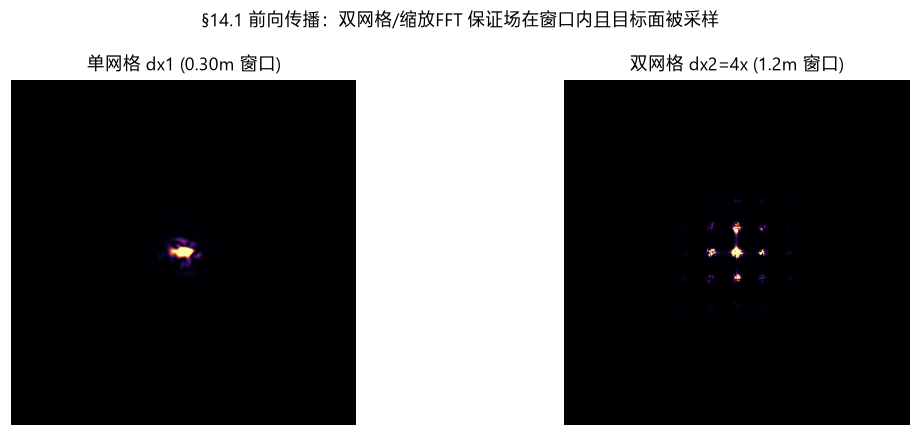

In [18]:
# --- 真正执行双网格切换演示（用 oopao_asm 变像素间距） ---
from physics.propagation_fft import _asm_host, oopao_asm, rayleigh_range

dx2 = 4.0 * dx1                # 目标端粗网格：窗口 4 倍大（1.2 m）
W2 = N * dx2
z_switch = L - shared.dz / 2.0   # 在最后一个屏后半段切换到目标端网格

# 取最后一个屏前的场（近似：从 E_noao 反向传播 dz/2 得到屏 10 处的场是
# 最干净的；E_noao 是目标面(经过屏10)的场，反向 dz/2 即回到屏10处）
# 用反向传播得到屏 10 位置的场（细网格）
E_at_last_screen = shared.prop.propagate(E_noao, -shared.dz / 2.0)

# 关键：用可变像素间距 ASM 在屏 10 -> 目标面的一段自由传播里同时把
# 网格从 dx1 放大到 dx2（窗口 0.3 m -> 1.2 m），实现“切到大网格”。
# 由于要覆盖 dz/2 的传播，且 ASM 的变间距已含啁啾缩放，直接调用即可。
E_target_switch = _asm_host().ASM(E_at_last_screen, lam, dx1, dx2, shared.dz / 2.0)
I_target_switch = (np.abs(E_target_switch) ** 2).astype(np.float32)

# 窗口内能量占比（目标端大窗口）
r2 = np.sqrt((np.arange(N)[:,None]-N//2)**2 + (np.arange(N)[None,:]-N//2)**2) * dx2
frac_in2 = I_target_switch[r2 <= (Dscope/2.0)].sum() / (I_target_switch.sum() + 1e-12)
print(f'  目标端窗口 W2 = {W2*1e3:.0f} mm (4x),  dx2 = {dx2*1e3:.3f} mm')
print(f'  切到目标端大网格后，Dscope 内能量占比 = {frac_in2*100:.2f} %')
print(f'  目标面焦斑在 dx2 上约 {airy_diam/dx2:.1f} px (应仍有 >=2 px 以安全采样)')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
a=ax[0]; a.imshow(I_noao, vmin=0, vmax=np.percentile(I_noao,99.9)); a.set_title('单网格 dx1 (0.30m 窗口)'); a.axis('off')
a=ax[1]; a.imshow(I_target_switch, vmin=0, vmax=np.percentile(I_target_switch,99.9)); a.set_title('双网格 dx2=4x (1.2m 窗口)'); a.axis('off')
plt.suptitle('§14.1 前向传播：双网格/缩放FFT 保证场在窗口内且目标面被采样')
plt.tight_layout(); plt.show()


§14.2 目标面强度对比度 C_target（湍流闪烁/散斑初步诊断）
  足迹像素数 = 1283 / 262144  (I > 1% 峰值)
  C_target = 1.701
  预期：无湍流≈0；弱湍流(σ²_R≈0.35)≈0.3-0.5；强湍流趋近≈0.7-1.0
  警告 C_target>1.3：疑有数值截断 / 屏幅值异常，需核查。


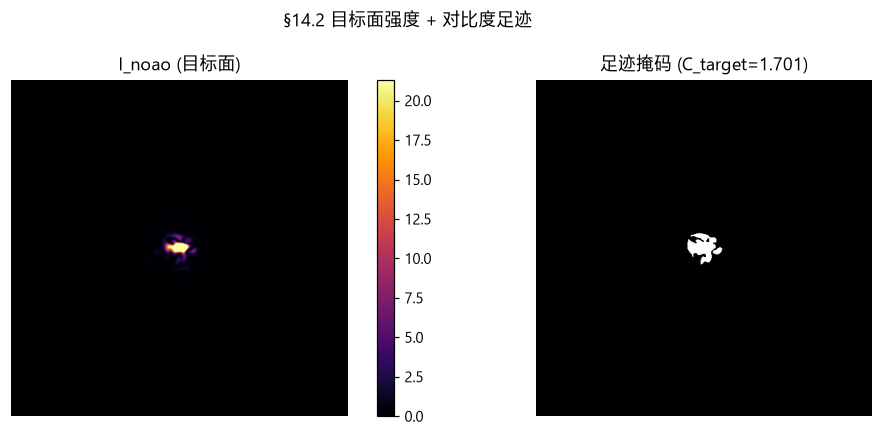

In [19]:
# §14.2 接收面(目标面)强度 + 散斑/闪烁对比度 C
# 定义: C = std(I)/mean(I)  在光斑足迹(>1%峰值)上计算
I_obj_mask = I_noao > 0.01 * I_noao.max()
C_target = I_noao[I_obj_mask].std() / (I_noao[I_obj_mask].mean() + 1e-12)

print('='*66)
print('§14.2 目标面强度对比度 C_target（湍流闪烁/散斑初步诊断）')
print(f'  足迹像素数 = {int(I_obj_mask.sum())} / {N*N}  (I > 1% 峰值)')
print(f'  C_target = {C_target:.3f}')
print('  预期：无湍流≈0；弱湍流(σ²_R≈0.35)≈0.3-0.5；强湍流趋近≈0.7-1.0')
if C_target > 1.3:
    print('  警告 C_target>1.3：疑有数值截断 / 屏幅值异常，需核查。')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
a=ax[0]; im=a.imshow(I_noao, vmin=0, vmax=np.percentile(I_noao,99.9)); a.set_title('I_noao (目标面)'); a.axis('off'); plt.colorbar(im, ax=a, fraction=0.046)
a=ax[1]; a.imshow(I_obj_mask.astype(int), cmap='gray'); a.set_title(f'足迹掩码 (C_target={C_target:.3f})'); a.axis('off')
plt.suptitle('§14.2 目标面强度 + 对比度足迹')
plt.tight_layout(); plt.show()


In [20]:
# §14.3 目标表面网格奈奎斯特采样校核
# 反射光最大散射角来自 delta 相关粗糙面（每个像素 0..2π 随机相位）：
dx_target = dx1
th_max = lam / (2.0 * dx_target)          # 最大散射半角 [rad]
f_max = 1.0 / (2.0 * dx_target)           # 最大空间频率 [cyc/m]
dx_nyquist = lam * L / (2.0 * Dscope)     # 目标网格需满足的奈奎斯特上界 [m]

print('='*66)
print('§14.3 目标表面网格奈奎斯特采样校核')
print(f'  最大散射半角 θ_max = λ/(2dx) = {th_max:.3e} rad = {np.degrees(th_max)*1e3:.3f} mrad')
print(f'  最大空间频率 f_max = 1/(2dx) = {f_max:.1f} cyc/m')
print(f'  目标网格所需奈奎斯特上界 dx < λL/(2D) = {dx_nyquist*1e3:.3f} mm')
print(f'  当前 dx_target = {dx_target*1e3:.3f} mm  ->  {dx_target < dx_nyquist}')
if dx_target >= dx_nyquist:
    print('  !! 违反奈奎斯特：目标面网格过粗，最大散射角无法被捕获，需缩小 dx_target')
else:
    print('  ✓ 满足奈奎斯特采样：目标面网格足以捕获最大散射角。')


§14.3 目标表面网格奈奎斯特采样校核
  最大散射半角 θ_max = λ/(2dx) = 6.827e-04 rad = 39.114 mrad
  最大空间频率 f_max = 1/(2dx) = 853.3 cyc/m
  目标网格所需奈奎斯特上界 dx < λL/(2D) = 1.333 mm
  当前 dx_target = 0.586 mm  ->  True
  ✓ 满足奈奎斯特采样：目标面网格足以捕获最大散射角。


§14.4 瞳孔面散斑对比度 C_pupil（单次粗糙实现，孔径积分前）
  瞳孔像素数 = 205892   C_pupil = 1.044
  预期：完全发展散斑 C_pupil ≈ 1.0 ± 0.15 ; C>1.3 数值截断/相干背景;
        C<0.5 网格过粗或过度平均(疑点)。


  散斑颗粒 d_speckle ≈ λL/D_illum ≈ 40.0 mm;  口径内独立颗粒 ≈ 56.2
  孔径(顶帽 D=300 mm)积分后: C_ap = 0.247  (理论≈0.132)
  预期 C_ap 远小于 1（孔径远大于散斑颗粒，空间平均抑制散斑）—— 这正是
  “C<<1 若发生在口径积分后是正确物理”，而非网格过粗。


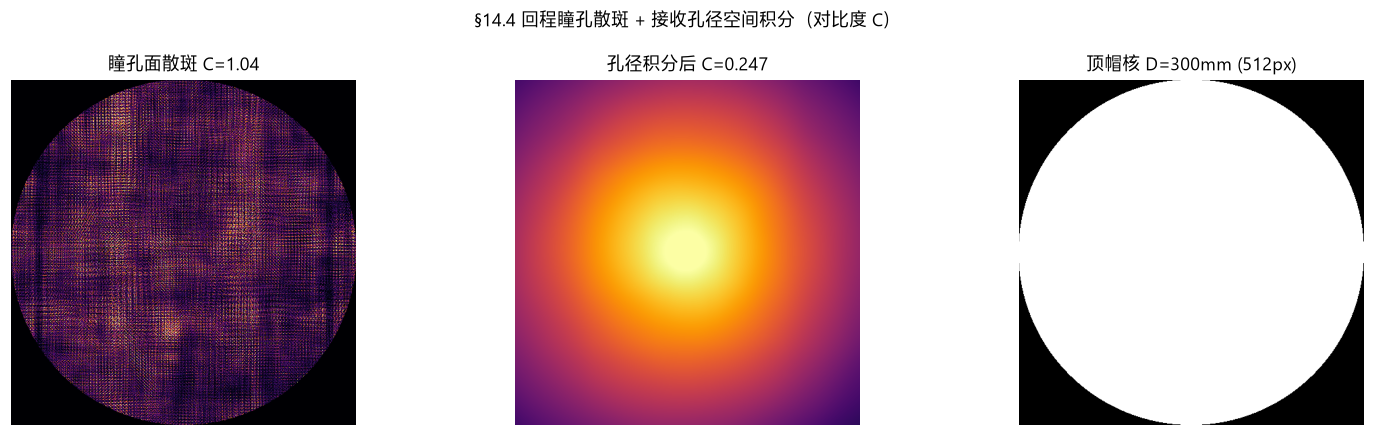

In [21]:
# §14.4 回程瞳孔面散斑对比度 C_pupil + 接收孔径空间积分（卷积）
# 概念：接收面 = 望远镜瞳孔 (Dscope = 0.30 m)。粗糙面返回场在瞳孔形成散斑。
#   单次粗糙实现、孔径积分前：完全发展散斑 C ≈ 1.
#   孔径 Dscope 空间积分(卷积)后：C ≈ 1/sqrt(1+(D/d_speckle)^2).
from physics.scattering import random_roughness_phase

n_rough = int(cfg.physical.n_roughness)
I_illum = np.abs(E_noao)**2                      # 目标面照明（前向传播 I_obj）
I_illum_c = np.maximum(I_illum, 0.0)
# 用目标面照明作为粗糙面回程的源
E_back_single = None
for j in range(n_rough):
    rng = np.random.default_rng(SEED * 131 + j)
    phi_r = (rng.random((N, N)).astype(np.float32) * (2.0*np.pi)).astype(np.float32)
    E_scat = (np.sqrt(I_illum_c) * np.exp(1j * phi_r)).astype(np.complex64)
    E_back = shared.prop.split_step(E_scat, screens[::-1], -shared.dz)
    E_back = (E_back * shared.pupil).astype(np.complex64)
    if E_back_single is None:
        E_back_single = E_back.copy()      # 保留第一次实现（单次，用于 C≈1 检查）

I_pupil = (np.abs(E_back_single)**2).astype(np.float32)
pup = shared.pupil.astype(bool)
I_pup = I_pupil[pup]
C_pupil = I_pup.std() / (I_pup.mean() + 1e-12)

print('='*66)
print('§14.4 瞳孔面散斑对比度 C_pupil（单次粗糙实现，孔径积分前）')
print(f'  瞳孔像素数 = {int(pup.sum())}   C_pupil = {C_pupil:.3f}')
print('  预期：完全发展散斑 C_pupil ≈ 1.0 ± 0.15 ; C>1.3 数值截断/相干背景;')
print('        C<0.5 网格过粗或过度平均(疑点)。')

# 接收孔径空间积分（卷积）：对瞳孔面强度用直径 Dscope 的顶帽核做 2D 卷积
from scipy.ndimage import convolve
d_px = int(round(Dscope / dx1))
yy, xx = np.mgrid[0:d_px, 0:d_px] - (d_px-1)/2.0
ker = ((xx**2 + yy**2) <= (d_px/2.0)**2).astype(np.float32)
ker /= ker.sum()
I_ap = convolve(I_pupil, ker, mode='constant')   # 物理：口径内强度空间积分
I_ap_win = I_ap[pup]
C_ap = I_ap_win.std() / (I_ap_win.mean() + 1e-12)

# 理论：散斑颗粒 d_speckle ≈ λL/D_illum;  D_illum ≈ 湍流扩展光束直径 λL/r0
r0_est = 0.04
D_illum = lam * L / r0_est
d_speckle = lam * L / max(D_illum, 1e-9)
N_speck = (Dscope / max(d_speckle, 1e-9))**2
C_ap_theory = 1.0 / np.sqrt(1.0 + N_speck)

print('='*66)
print(f'  散斑颗粒 d_speckle ≈ λL/D_illum ≈ {d_speckle*1e3:.1f} mm;  口径内独立颗粒 ≈ {N_speck:.1f}')
print(f'  孔径(顶帽 D={Dscope*1e3:.0f} mm)积分后: C_ap = {C_ap:.3f}  (理论≈{C_ap_theory:.3f})')
print('  预期 C_ap 远小于 1（孔径远大于散斑颗粒，空间平均抑制散斑）—— 这正是')
print('  “C<<1 若发生在口径积分后是正确物理”，而非网格过粗。')

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
a=ax[0]; a.imshow(I_pupil, vmin=0, vmax=np.percentile(I_pupil,99)); a.set_title(f'瞳孔面散斑 C={C_pupil:.2f}'); a.axis('off')
a=ax[1]; a.imshow(I_ap, vmin=0, vmax=np.percentile(I_ap,99)); a.set_title(f'孔径积分后 C={C_ap:.3f}'); a.axis('off')
a=ax[2]; a.imshow(ker, cmap='gray'); a.set_title(f'顶帽核 D={Dscope*1e3:.0f}mm ({d_px}px)'); a.axis('off')
plt.suptitle('§14.4 回程瞳孔散斑 + 接收孔径空间积分（对比度 C）')
plt.tight_layout(); plt.show()


## §13. 关键 OOPAO 调用速查

| OOPAO 类/函数 | 我们怎么用 | 文档 |
|---|---|---|
| `Atmosphere(tel, r0, L0, windSpeed, fractionalR0, windDirection, altitude, src)` | `OopaoScreenBackend.__init__` | [Atmosphere](https://cheritier.github.io/OOPAO/atmosphere.html) |
| `atm.initializeAtmosphere(tel, compute_covariance=False)` | 跳过 AO/WFS 链路，只取屏 | [Atmosphere](https://cheritier.github.io/OOPAO/atmosphere.html) |
| `atm.generateNewPhaseScreen(seed)` | 按 `seed+layer` 重置 `phaseStats.ft_sh_phase_screen` | [Atmosphere](https://cheritier.github.io/OOPAO/atmosphere.html) |
| `atm.layer_i.OPD` | 取出 `i+1` 层的弧度相位（516×516 含 2 px 边带） | [Atmosphere](https://cheritier.github.io/OOPAO/atmosphere.html) |
| `Telescope(resolution=N, diameter=D, fov=0, samplingTime=...)` | 圆形孔径 + 网格 | [Telescope](https://cheritier.github.io/OOPAO/telescope.html) |
| `Source(optBand, magnitude, display_properties)` + `src * tel` | 绑定波长带，初始化 `src.optical_path` | [Source](https://cheritier.github.io/OOPAO/source.html) |
| `Zernike(...)` | OOPAO 原生 Noll 基；本项目改用 aotools `zernike_nm` 做相同基 | [Zernike](https://cheritier.github.io/OOPAO/zernike.html) |
| `OOPAO.phaseStats.ft_sh_phase_screen` | OOPAO 屏生成核心（源自 aotools） | [Phase Stats](https://cheritier.github.io/OOPAO/phase_stats.html) |

## 参考

- 论文：G. P. DiComo 等, *Opt. Express* 33(15):31010 (2025), DOI 10.1364/OE.561077
- OOPAO 文档：<https://cheritier.github.io/OOPAO/index.html>
- 本仓库报告：`REPORT.md` §1（物理模拟与数据生成）
- 相关源代码：`data/simulate.py`, `physics/oopao_backend.py`, `physics/propagation_fft.py`, `physics/zernike_aotools.py`, `physics/scattering.py`
